In [1]:
import sys 
sys.path.append("/Users/shubham/Documents/Github/acceleration-flow-matching/src")


In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import LatentViT
from vae import SpatialVae
from data_loader import train_loader
from tqdm import tqdm
from diffusion import DDIMSampler, DDIMSpatialLatent
from utils import visualize_samples

In [3]:
device = 'cpu'
model = LatentViT(latent_channels=16, embed_dim=192, depth=12, num_heads=3)
model.load_state_dict(torch.load('/Users/shubham/Downloads/ddpm_latent_model_150.pth', map_location=torch.device(device), weights_only=True))#['model_state_dict'])
model = model.to(device)

vae = SpatialVae(in_channels=1)
vae.load_state_dict(torch.load('spatial_vae_mnist.pth', map_location=torch.device('cpu'), weights_only=True))

model_ddim = DDIMSpatialLatent(model, vae=vae)


In [22]:
sampler = model_ddim
sampler.model.eval()

# Cell 4: Test and Benchmark

# Generate samples
z_noise = torch.randn(4, 16, 8, 8, device=device)

x_samples = None
for i in range(10):
    if x_samples is None:
        x_samples = sampler.sample(z_noise, torch.tensor([i]), t_steps=400, eta=1.0, verbose=True)
    else:
        x_samples = torch.concatenate([x_samples,sampler.sample(z_noise, torch.tensor([i]), t_steps=400, eta=1.0, verbose=True)], dim=0)
    

DDIM: 100%|██████████| 400/400 [00:07<00:00, 56.69it/s]


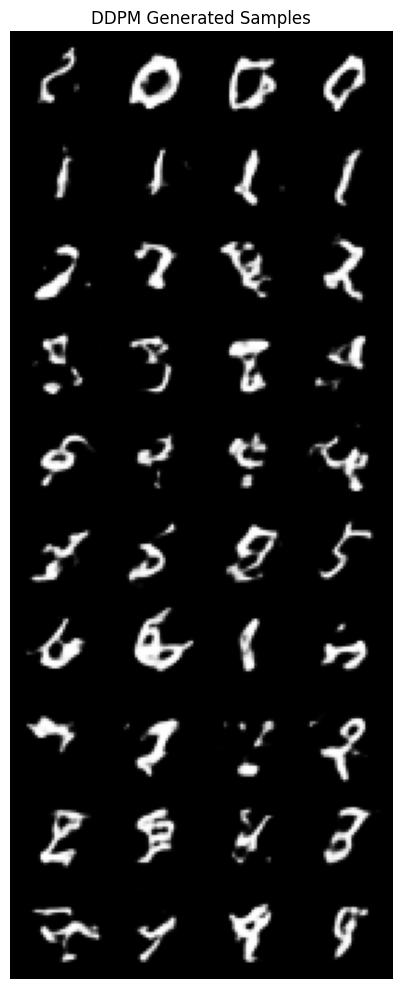

In [24]:
# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")